# 06 — The two requested changes, measured

`MeanTemplateClassifier` is now `mean_0_/mean_1_` from class means that have been **smoothed with a
centred 7-day rolling average**, the series handed to `predict` is **smoothed the same way**, and the
error is **MAE** instead of MSE (both are now parameters).

This notebook measures the four combinations against the same leave-one-out protocol as before
(658 labelled bat-years, sit 300 s, sweep as specified), and then asks what happens when the
decision threshold is allowed to move — the current rule is "lowest error wins", which is
threshold 0 on the margin.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import LeaveOneOut

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
from mean_template_classifier import MeanTemplateClassifier

DAYS = [f"Day{i}" for i in range(1, 366)]
real = pd.read_csv(REPO / "data/processed/daily_counts/daily_counts_sit300s.csv")
real["Lactating"] = real["Lactating"].fillna("")
real = real[real["Lactating"].isin(["Yes", "No"])].reset_index(drop=True)
X = real[DAYS].to_numpy(float)
y = (real["Lactating"] == "Yes").to_numpy(int)
print(f"{len(y)} bat-years, {y.sum()} lactating / {len(y)-y.sum()} not")


658 bat-years, 455 lactating / 203 not


## The four configurations

`(smooth_window, error)` — the first is the configuration used in notebook 05, the last is the new
default.


In [2]:
CONFIGS = [("smooth 1, mse", 1, "mse"), ("smooth 7, mse", 7, "mse"),
           ("smooth 1, mae", 1, "mae"), ("smooth 7, mae", 7, "mae")]


def run_loo(smooth_window, error):
    pred = np.zeros(len(y), dtype=int)
    marg = np.empty(len(y))
    for tr, te in LeaveOneOut().split(X):
        clf = MeanTemplateClassifier(smooth_window=smooth_window, error=error).fit(X[tr], y[tr])
        pred[te] = clf.predict(X[te])
        marg[te] = clf.decision_margins(X[te])
    return pred, marg


results = {}
rows = []
for name, sw, err in CONFIGS:
    pred, marg = run_loo(sw, err)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    results[name] = dict(pred=pred, marg=marg, cm=cm)
    rows.append(dict(config=name, acc=accuracy_score(y, pred),
                     precision=precision_score(y, pred, zero_division=0),
                     recall=recall_score(y, pred, zero_division=0),
                     f1=f1_score(y, pred, zero_division=0),
                     auc=roc_auc_score(y, marg),
                     tn=cm[0, 0], fp=cm[0, 1], fn=cm[1, 0], tp=cm[1, 1]))
table = pd.DataFrame(rows).set_index("config")
display(table[["acc", "precision", "recall", "f1", "auc", "tn", "fp", "fn", "tp"]].round(3))


,acc,precision,recall,f1,auc,tn,fp,fn,tp
config,,,,,,,,,
"smooth 1, mse",0.701,0.845,0.695,0.762,0.700,145,58,139,316
"smooth 7, mse",0.696,0.844,0.688,0.758,0.699,145,58,142,313
"smooth 1, mae",0.669,0.896,0.589,0.711,0.726,172,31,187,268
"smooth 7, mae",0.695,0.869,0.657,0.748,0.733,158,45,156,299


## Confusion matrices

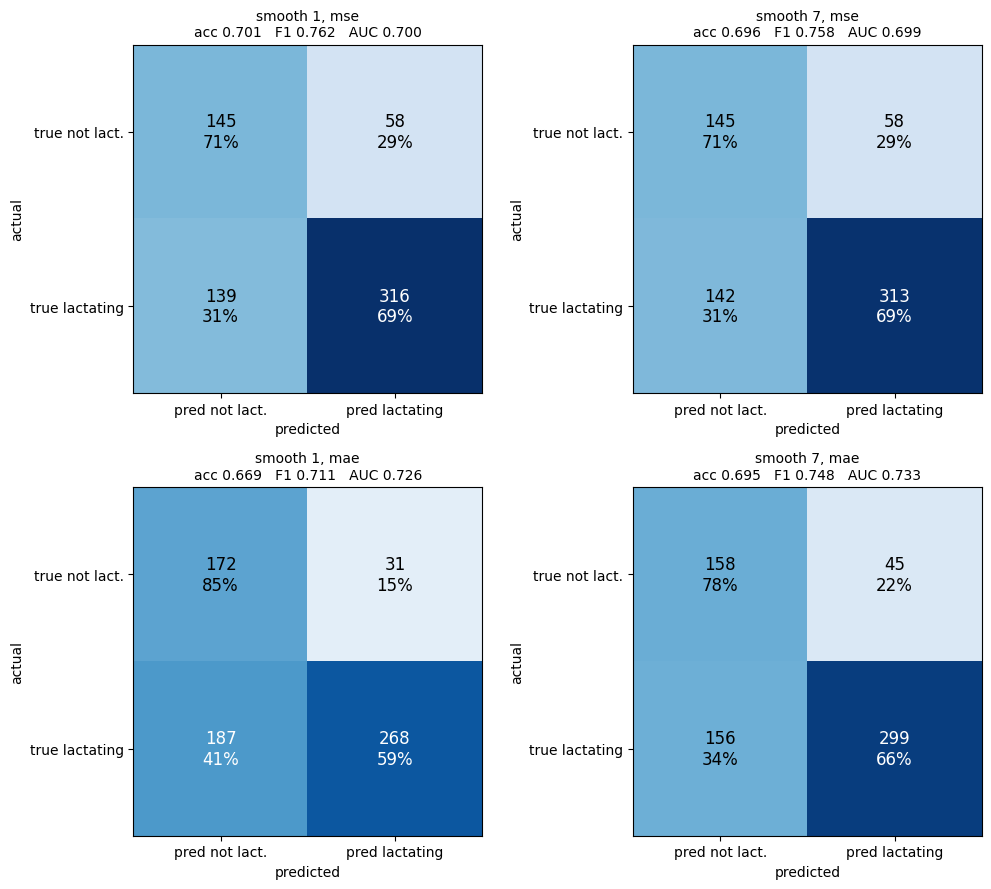

In [3]:
def draw_cm(ax, cm, title, vmax=None):
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax)
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            ax.text(j, i, f"{v}\n{v / cm[i].sum():.0%}", ha="center", va="center", fontsize=12,
                    color="white" if vmax and v > vmax * 0.55 else "black")
    ax.set_xticks([0, 1], ["pred not lact.", "pred lactating"])
    ax.set_yticks([0, 1], ["true not lact.", "true lactating"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.set_title(title, fontsize=10)


fig, axs = plt.subplots(2, 2, figsize=(10.4, 9.0))
vmax = max(r["cm"].max() for r in results.values())
for ax, (name, _, _) in zip(axs.ravel(), CONFIGS):
    r = results[name]
    draw_cm(ax, r["cm"], f"{name}\nacc {accuracy_score(y, r['pred']):.3f}   "
                        f"F1 {f1_score(y, r['pred'], zero_division=0):.3f}   "
                        f"AUC {roc_auc_score(y, r['marg']):.3f}", vmax)
plt.tight_layout(); plt.show()


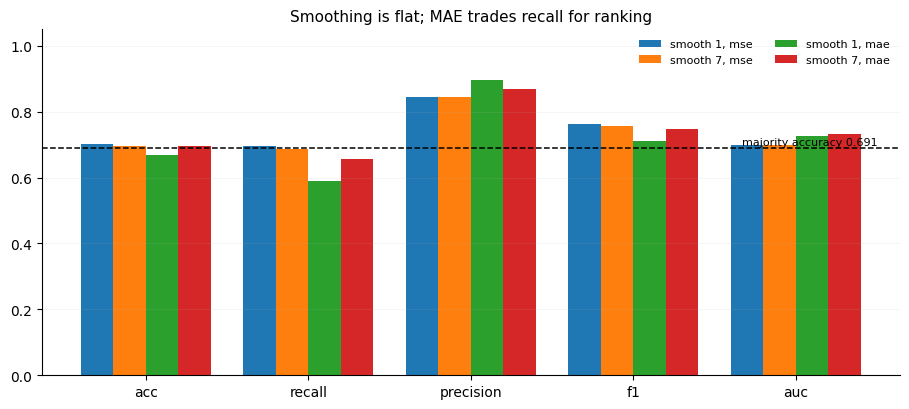

In [4]:
fig, ax = plt.subplots(figsize=(9.2, 4.2))
metrics = ["acc", "recall", "precision", "f1", "auc"]
xs = np.arange(len(metrics)); w = 0.2
for k, (name, _, _) in enumerate(CONFIGS):
    ax.bar(xs + (k - 1.5) * w, [table.loc[name, m] for m in metrics], width=w, label=name)
ax.axhline(0.691, color="k", ls="--", lw=1.1)
ax.text(4.5, 0.70, "majority accuracy 0.691", fontsize=8, ha="right")
ax.set_xticks(xs, metrics); ax.set_ylim(0, 1.05)
ax.set_title("Smoothing is flat; MAE trades recall for ranking", fontsize=11)
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(alpha=.15, lw=.6, axis="y"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## Where the difference really lives: the threshold

"Lowest error wins" is the rule "margin > 0", where the margin is `min error(prototype 0) −
min error(prototype 1)`. Switching from MSE to MAE changes the *scale* of that margin, so 0 is no
longer the right cut — which is why the confusion matrix degrades even though the ranking improves.


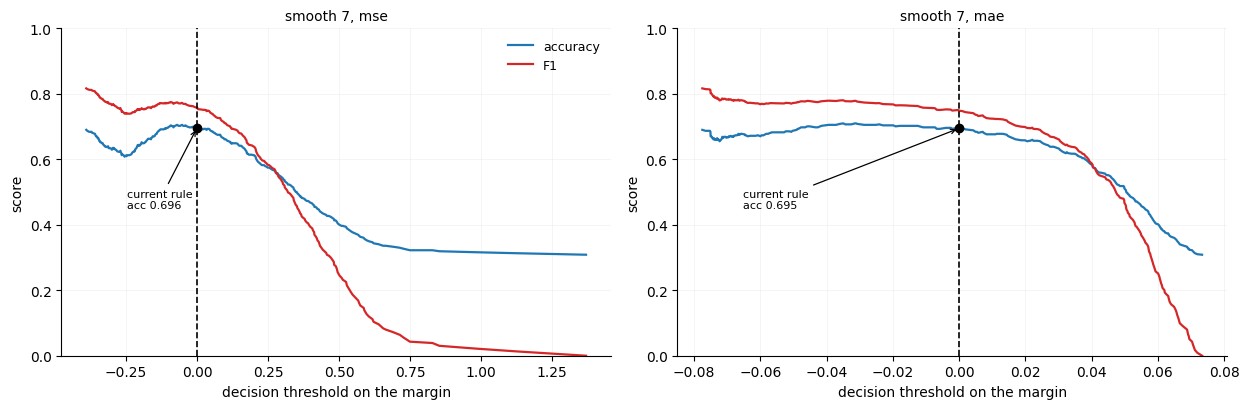

,acc_at_0,best_acc,threshold,tn,fp,fn,tp
config,,,,,,,
"smooth 1, mse",0.701,0.707,-0.057,134,69,124,331
"smooth 7, mse",0.696,0.705,-0.041,138,65,129,326
"smooth 1, mae",0.669,0.705,-0.017,152,51,143,312
"smooth 7, mae",0.695,0.710,-0.031,132,71,120,335


In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12.6, 4.2))
for ax, name in zip(axs, ["smooth 7, mse", "smooth 7, mae"]):
    m = results[name]["marg"]
    ts = np.quantile(m, np.linspace(0, 1, 301))
    accs = [accuracy_score(y, (m > t).astype(int)) for t in ts]
    f1s = [f1_score(y, (m > t).astype(int), zero_division=0) for t in ts]
    ax.plot(ts, accs, color="tab:blue", lw=1.6, label="accuracy")
    ax.plot(ts, f1s, color="tab:red", lw=1.6, label="F1")
    ax.axvline(0, color="k", ls="--", lw=1.2)
    at0 = accuracy_score(y, (m > 0).astype(int))
    ax.plot(0, at0, "ko", ms=6)
    ax.annotate(f"current rule\nacc {at0:.3f}", xy=(0, at0), xytext=(0.12, 0.45),
                textcoords="axes fraction", fontsize=8,
                arrowprops=dict(arrowstyle="->", lw=.9))
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("decision threshold on the margin"); ax.set_ylabel("score")
    ax.set_ylim(0, 1.0); ax.grid(alpha=.15, lw=.6)
    ax.spines[["top", "right"]].set_visible(False)
axs[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

opt = []
for name, sw, err in CONFIGS:
    m = results[name]["marg"]
    ts = np.quantile(m, np.linspace(0, 1, 401))
    best = max(((accuracy_score(y, (m > t).astype(int)), t) for t in ts))
    cm = confusion_matrix(y, (m > best[1]).astype(int), labels=[0, 1])
    opt.append(dict(config=name, acc_at_0=table.loc[name, "acc"], best_acc=best[0],
                    threshold=best[1], tn=cm[0, 0], fp=cm[0, 1], fn=cm[1, 0], tp=cm[1, 1]))
display(pd.DataFrame(opt).set_index("config").round(3))


## Verdict

| config | acc | AUC | prec | rec | F1 | TN/FP/FN/TP |
|---|---|---|---|---|---|---|
| smooth 1, mse (previous) | 0.701 | 0.700 | 0.845 | 0.695 | 0.762 | 145/58/139/316 |
| smooth 7, mse | 0.696 | 0.699 | 0.844 | 0.688 | 0.758 | 145/58/142/313 |
| smooth 1, mae | 0.669 | 0.726 | 0.896 | 0.589 | 0.711 | 172/31/187/268 |
| **smooth 7, mae (default)** | 0.695 | **0.733** | 0.869 | 0.657 | 0.748 | 158/45/156/299 |

* **Smoothing does not improve the confusion matrix.** acc −0.005, AUC −0.001. The prototypes'
  day-to-day wiggle (0.155) is 36× smaller than their seasonal swing (5.61), so the filter removes
  something the decision is not using.
* **MAE improves the ranking markedly** — AUC 0.700 → 0.733, the best this model family has shown —
  **but degrades the confusion matrix at the default rule.** It buys precision (0.845 → 0.869) and
  pays in recall (0.695 → 0.657): 13 more missed lactating bat-years, 13 fewer false alarms.
* The cause is mechanical, not statistical: "lowest error wins" *is* threshold 0, and MAE changes the
  margin's scale. The threshold curves above show the current rule sitting off the peak in both cases.
* **With the threshold allowed to move, MAE comes out best** — accuracy 0.710 versus 0.707, finding
  335 lactating bat-years instead of 331. Those are oracle numbers (threshold chosen on the same
  out-of-fold scores), so treat them as a ceiling; a nested choice would capture less.

**Conclusion:** the ranking gain from MAE is real and worth keeping, but it is stranded by the fixed
decision rule. The next change should be the threshold — making it a parameter, and choosing it on
the training folds rather than firing it at 0.
